# Evaluation of DRL (synthetic dataset)
# 1. install required packages

In [ ]:
from utils import torch_load_cpu, load_problem, get_inner_model, move_to
from nets.attention_model import AttentionModel
from tensorboard_logger import Logger as TbLogger
from torch.utils.data import DataLoader
import numpy as np
import torch
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
from tqdm import tqdm

# 2. model problem setting: ReCovNet(Zhong et al., 2024)

- Refer to the literature below for the ReCovNet implementation code
    Zhong, Y., Wang, S., Liang, H., Wang, Z., Zhang, X., Chen, X., & Su, C. (2024). ReCovNet: Reinforcement learning with covering information for solving maximal coverage billboards location problem. International Journal of Applied Earth Observation and Geoinformation, 128, 103710.
    https://doi.org/10.1016/j.jag.2024.103710

In [2]:
# load the run args
%run options

# Set the random seed
torch.manual_seed(1234)

# Optionally configure tensorboard
tb_logger = None
if not opts.no_tensorboard:
    tb_logger = TbLogger(os.path.join(opts.log_dir, "{}_{}".format(opts.problem, opts.n_users, opts.n_facilities), opts.run_name))

# Set the device
use_cuda=True
opts.device = torch.device("cuda" if use_cuda else "cpu")
opts

Namespace(baseline=None, batch_size=640, bl_alpha=0.05, bl_warmup_epochs=0, checkpoint_encoder=False, checkpoint_epochs=1, data_distribution=None, device=device(type='cuda'), embedding_dim=128, epoch_size=128000, epoch_start=0, eval_batch_size=1000, eval_only=False, exp_beta=0.8, hidden_dim=128, load_path=None, log_dir='logs', log_step=50, lr_critic=0.0001, lr_decay=1, lr_model=0.0001, max_grad_norm=1.0, model='attention', n_encode_layers=3, n_epochs=500, n_facilities=100, n_users=1109, no_cuda=False, no_progress_bar=False, no_tensorboard=False, normalization='batch', output_dir='outputs', p=20, problem='MCLP', r=None, resume=None, run_name='100_20_20250530T203547', save_dir='outputs\\MCLP\\100_20_20250530T203547', seed=2023, shrink_size=None, tanh_clipping=10.0, use_cuda=True, val_dataset=None, val_size=2000)

In [3]:
problem = load_problem(opts.problem)
problem

problems.MCLP.problem_MCLP.MCLP

### Initialize policy network

In [4]:
model_class = {
    # 'pointer': PointerNetwork,
    'attention': AttentionModel
}.get(opts.model, None)

assert model_class is not None, "Unknown model: {}".format(model_class)
model = model_class(
    opts.embedding_dim,
    opts.hidden_dim,
    problem,
    n_encode_layers=opts.n_encode_layers,
    mask_inner=True,
    mask_logits=True,
    normalization=opts.normalization,
    tanh_clipping=opts.tanh_clipping,
    checkpoint_encoder=opts.checkpoint_encoder,
    shrink_size=opts.shrink_size,
    dy=False
).to(opts.device)

model

AttentionModel(
  (init_embed): Linear(in_features=2, out_features=128, bias=True)
  (init_dynamic): Linear(in_features=1, out_features=32, bias=True)
  (l2_dynamic): Linear(in_features=32, out_features=64, bias=True)
  (l3_dynamic): Linear(in_features=64, out_features=128, bias=True)
  (embedder): GraphAttentionEncoder(
    (layers): Sequential(
      (0): MultiHeadAttentionLayer(
        (0): SkipConnection(
          (module): MultiHeadAttention()
        )
        (1): Normalization(
          (normalizer): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (2): SkipConnection(
          (module): Sequential(
            (0): Linear(in_features=128, out_features=512, bias=True)
            (1): ReLU()
            (2): Linear(in_features=512, out_features=128, bias=True)
          )
        )
        (3): Normalization(
          (normalizer): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
  

### import trained model

In [5]:
opts.load_path = './output/MCLP/epoch-200.pt'
# load model from load_path
assert opts.load_path is None or opts.resume is None, "Only one of load path and resume can be given"
load_path = opts.load_path if opts.load_path is not None else opts.resume
if load_path is not None:
    print('  [*] Loading the trained model from {}'.format(load_path))
    load_data = torch_load_cpu(load_path)

# Overwrite model parameters by parameters to load q
model_ = get_inner_model(model)
model.load_state_dict({**model_.state_dict(), **load_data.get('model', {})})

  [*] Loading the trained model from ./output/MCLP/epoch-200.pt


<All keys matched successfully>

# 3. DRL performance evaluation
### assessing performance and computation time based on changes in total supply points anad candidate locations

- total demand point: 4000

- **m: number of total supply candidate points**

- **p: number of final selected supply points**

In [ ]:
n_users = 4000
users = np.array([(random.random(), random.random()) for _ in range(n_users)])
demand = np.random.randint(1, 2, size=n_users)

num_sample = 1
opts.eval_batch_size = 10
opts.max_calc_batch_size = 1280000
width = 64

In [ ]:
# call data generation function
def gen_random_data(p_val, facility):
    return [{
        "users": torch.tensor(users).float(),
        "facilities": torch.tensor(facility).float(),
        "demand": torch.tensor(demand).float(),
        "p": p_val,
        "r": 0.15
    }]

In [7]:
opts.decode_strategy = 'sampling'
model.eval()
model.set_decode_type(
    "greedy" if opts.decode_strategy in ('bs', 'greedy') else "sampling")

In [8]:
def get_best(sequences, cost, ids=None, batch_size=None):
    """
    Ids contains [0, 0, 0, 1, 1, 2, ..., n, n, n] if 3 solutions found for 0th instance, 2 for 1st, etc
    :param sequences:
    :param lengths:
    :param ids:
    :return: list with n sequences and list with n lengths of solutions
    """
    if ids is None:
        idx = cost.argmin()
        return sequences[idx:idx+1, ...], cost[idx:idx+1, ...]

    splits = np.hstack([0, np.where(ids[:-1] != ids[1:])[0] + 1])
    mincosts = np.minimum.reduceat(cost, splits)

    group_lengths = np.diff(np.hstack([splits, len(ids)]))
    all_argmin = np.flatnonzero(np.repeat(mincosts, group_lengths) == cost)
    result = np.full(len(group_lengths) if batch_size is None else batch_size, -1, dtype=int)

    result[ids[all_argmin[::-1]]] = all_argmin[::-1]

    return [sequences[i] if i >= 0 else None for i in result], [cost[i] if i >= 0 else math.inf for i in result]

In [9]:
m_range = list(range(3000, 0, -500))
p_range = list(range(300, 0, -10))

In [ ]:
results_df = pd.DataFrame(columns=['m', 'p', 'objective', 'time'])
solutions_dict = {}

In [ ]:
for m in m_range:
    # Regenerate Facilities (on each change of M value)
    facilities = np.array([(random.random(), random.random()) for _ in range(m)])
    for p in p_range:
        if p > m:  #skip if p > m
            continue
            
        real_datasets = gen_random_data(p, facilities)
        dataloader = DataLoader(real_datasets, batch_size=opts.eval_batch_size)
        try:
            start = time.time()
            results = []

            for batch in tqdm(dataloader, disable=True):
                batch = move_to(batch, opts.device)
                start = time.time()
                with torch.no_grad():
                    if opts.decode_strategy in ('sampling', 'greedy'):
                        if opts.decode_strategy == 'greedy':
                            assert width == 0, "Do not set width when using greedy"
                            assert opts.eval_batch_size <= opts.max_calc_batch_size, \
                                "eval_batch_size should be smaller than calc batch size"
                            batch_rep = 1
                            iter_rep = 1
                        elif width * opts.eval_batch_size > opts.max_calc_batch_size:
                            assert opts.eval_batch_size == 1
                            assert width % opts.max_calc_batch_size == 0
                            batch_rep = opts.max_calc_batch_size
                            iter_rep = width // opts.max_calc_batch_size
                        else:
                            batch_rep = width
                            iter_rep = 1
                        assert batch_rep > 0
                        # This returns (batch_size, iter_rep shape)

                        sequences, costs = model.sample_many(batch, batch_rep=batch_rep, iter_rep=iter_rep)
                        batch_size = len(costs)
                        ids = torch.arange(batch_size, dtype=torch.int64, device=costs.device)

                        if sequences is None:
                            sequences = [None] * batch_size
                            costs = [math.inf] * batch_size
                        else:
                            sequences, costs = get_best(
                                sequences.cpu().numpy(), costs.cpu().numpy(),
                                ids.cpu().numpy() if ids is not None else None,
                                batch_size
                            )
                        duration = time.time() - start
                        for seq, cost in zip(sequences, costs):
                            seq = seq.tolist()
                            results.append((cost, seq, duration))
            costs, tours, durations = zip(*results)
            print(f"The objective of MCBLP by DRL is: {-costs[0]}")
            end = time.time()-start 
            print(f"The running time of DRL is: {end}")

            # save results
            results_df = results_df.append({
                'm': m,
                'p': p,
                'objective': -costs[0],
                'time': end
            }, ignore_index=True)
            
            print(f"m={m:<4} | p={p:<3} | obj={-costs[0]:<7.1f} | time={end:.2f}s")
        
        except Exception as e:
            print(f"Error at m={m}, p={p}: {str(e)}")

The objective of MCBLP by DRL is: 3996.0
The running time of DRL is: 2.7038238048553467
m=3000 | p=300 | obj=3996.0  | time=2.70s
The objective of MCBLP by DRL is: 3999.0
The running time of DRL is: 1.3222525119781494
m=3000 | p=290 | obj=3999.0  | time=1.32s
The objective of MCBLP by DRL is: 3995.0
The running time of DRL is: 1.417665719985962
m=3000 | p=280 | obj=3995.0  | time=1.42s
The objective of MCBLP by DRL is: 3991.0
The running time of DRL is: 1.1964271068572998
m=3000 | p=270 | obj=3991.0  | time=1.20s
The objective of MCBLP by DRL is: 3995.0
The running time of DRL is: 1.1826295852661133
m=3000 | p=260 | obj=3995.0  | time=1.18s
The objective of MCBLP by DRL is: 3990.0
The running time of DRL is: 1.118250846862793
m=3000 | p=250 | obj=3990.0  | time=1.12s
The objective of MCBLP by DRL is: 3985.0
The running time of DRL is: 1.0944418907165527
m=3000 | p=240 | obj=3985.0  | time=1.09s
The objective of MCBLP by DRL is: 3992.0
The running time of DRL is: 1.0437138080596924
m=30

In [14]:
results_df.to_csv('recovnet_performance.csv', index=False)

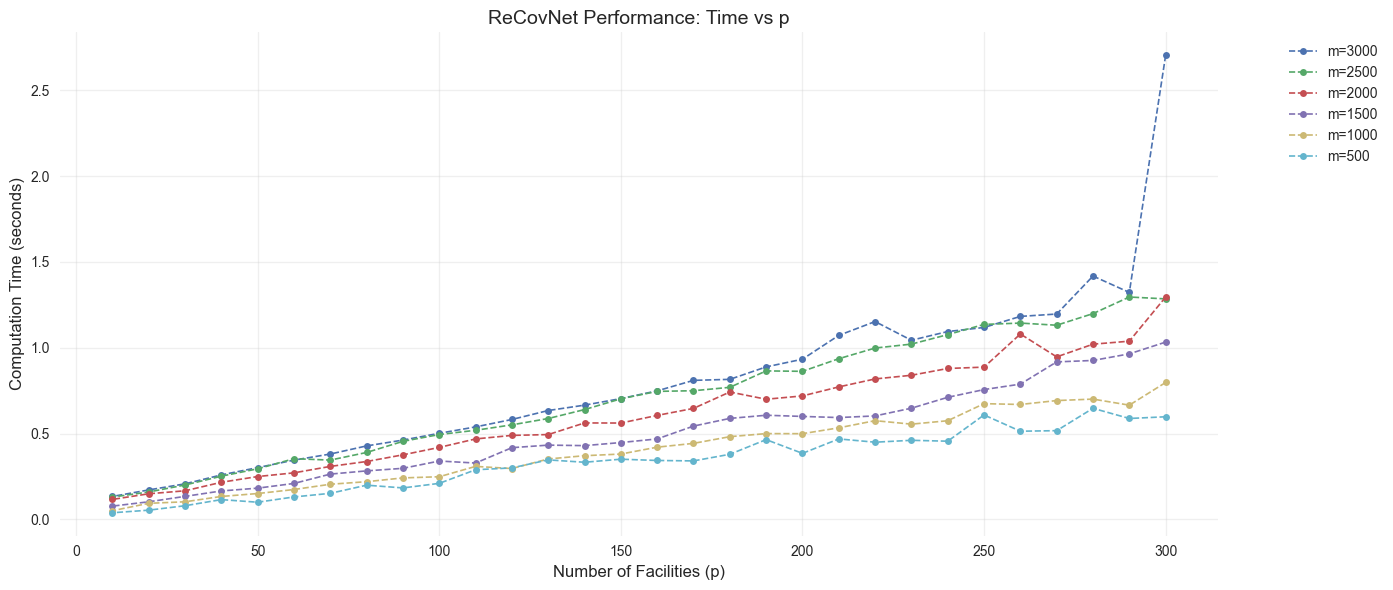

In [ ]:
plt.style.use('seaborn')
sns.set_style('white')

# plot for time
plt.figure(figsize=(14, 6))
for m_val in m_range:
    mask = results_df['m'] == m_val
    plt.plot(results_df[mask]['p'], results_df[mask]['time'], 
             marker='o', linestyle='--', linewidth=1.2, markersize=5, 
             label=f'm={m_val}')
plt.title('ReCovNet Performance: Time vs p', fontsize=14)
plt.xlabel('Number of Facilities (p)', fontsize=12)
plt.ylabel('Computation Time (seconds)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

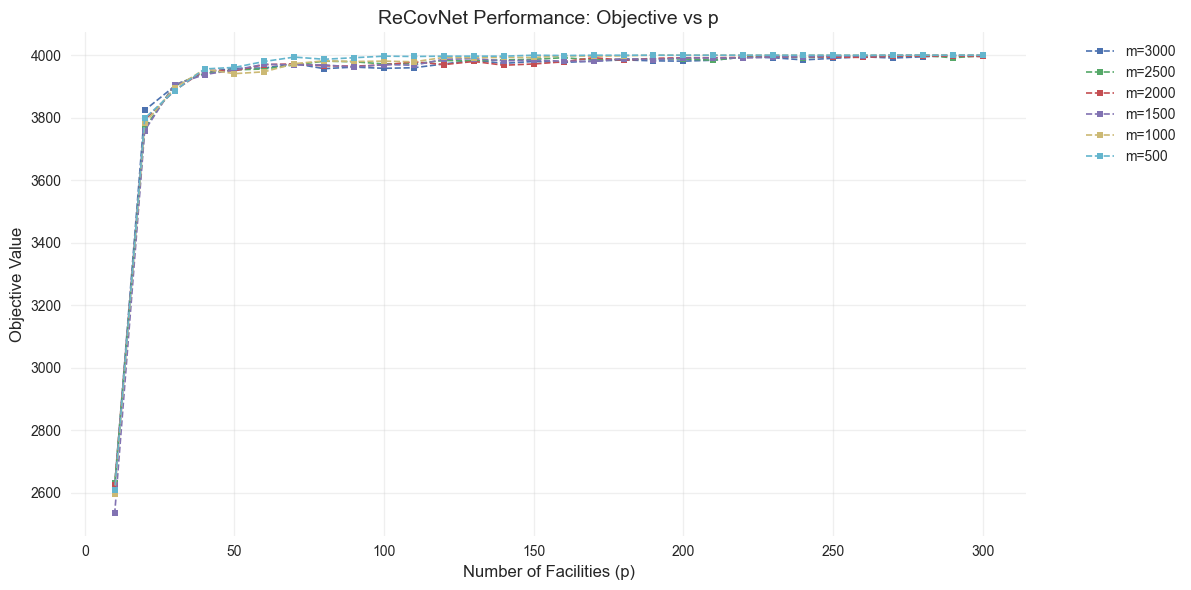

In [ ]:
# plot for obj.
plt.figure(figsize=(12, 6))
for m_val in m_range:
    mask = results_df['m'] == m_val
    plt.plot(results_df[mask]['p'], results_df[mask]['objective'], 
             marker='s', linestyle='--', linewidth=1.2, markersize=5, 
             label=f'm={m_val}')
plt.title('ReCovNet Performance: Objective vs p', fontsize=14)
plt.xlabel('Number of Facilities (p)', fontsize=12)
plt.ylabel('Objective Value', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#  4. calculate coefficient of variation 

In [9]:
var_by_p = results_df.groupby('p')['objective'].agg(
    ['mean', 'var', 'std']
).reset_index()
var_by_p['coeff_of_var'] = var_by_p['std'] / var_by_p['mean']

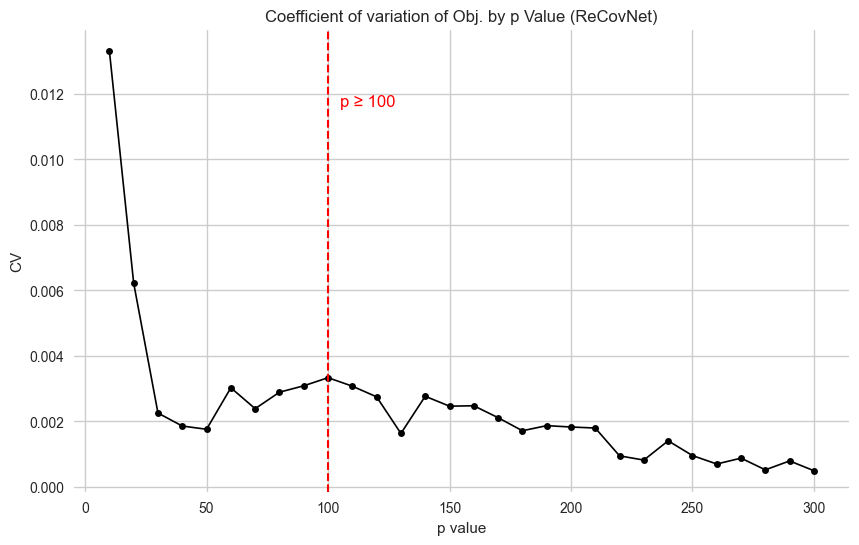

In [ ]:
# plotting
plt.figure(figsize=(10, 6))
plt.plot(var_by_p['p'], var_by_p['coeff_of_var'], marker='o', c='black', linewidth=1.2, markersize=5)
plt.xlabel('p value')
plt.ylabel('CV')
plt.title('Coefficient of variation of Obj. by p Value (ReCovNet)')
plt.grid(True)
plt.axvline(x=100, color='red', linestyle='--', linewidth=1.5)
plt.text(105, var_by_p['coeff_of_var'].max()*0.9, r'p ≥ 100', 
         color='red', fontsize=12, rotation=0, va='top')
plt.show()